In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.family':'arial',
    'font.size': 32,
    'font.weight':'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [3]:
import pandas as pd
import os

def split_and_save_dataframe(df, split_ratio, output_dir, filename_prefix):
    """
    Split a DataFrame and save parts as H5 files.
    
    Parameters:
    - df: pandas DataFrame to split
    - split_ratio: fraction of data to go to first file (0.0 to 1.0)
    - output_dir: directory to save files
    - filename_prefix: prefix for output filenames
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Split the DataFrame
    split_index = int(len(df) * split_ratio)
    df1 = df.iloc[:split_index]
    df2 = df.iloc[split_index:]
    
    # Create filenames
    file1 = os.path.join(output_dir, f"{filename_prefix}_part1.h5")
    file2 = os.path.join(output_dir, f"{filename_prefix}_part2.h5")
    
    # Save to HDF5 format
    df1.to_hdf(file1, key='data', mode='w')
    df2.to_hdf(file2, key='data', mode='w')
    
    print(f"Data saved to:\n- {file1}\n- {file2}")

# Example usage:
# df = pd.read_csv('your_large_file.csv')  # or however you load your data
# split_and_save_dataframe(df, 0.5, '/path/to/output/directory', 'my_data')

In [205]:
split_and_save_dataframe(light_dark,.5,r'\\goeppert\Vol2\mike\metadata\behavior_paper_data','light_dark')

Data saved to:
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5


In [4]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
    start_position = df[start_position_key].iloc[0].lower()
    
    # Set distance bins based on turn direction and start position
    if turn_direction == 'left' and start_position == 'bottom':
        distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
    elif turn_direction == 'right' and start_position == 'bottom':
        distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
    elif turn_direction == 'left' and start_position == 'top':
        distance_bins = np.arange(45, 0, -1) 
    elif turn_direction == 'right' and start_position == 'top':
        distance_bins = np.arange(9, 50, 1) 
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory

In [5]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [6]:
calculate_speed(light_dark)

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oa')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity.between(1.1,1.2))]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(15)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

In [1]:
data = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oa')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity.between(1.1,1.2))]
data =data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
sample_light = data.sample(1)
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

for ind,row in sample_light.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'tab:blue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(32,32),c ='black', linewidth = 2.5)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\single_trace_light.pdf",dpi = 300, transparent=True)

NameError: name 'light_dark' is not defined

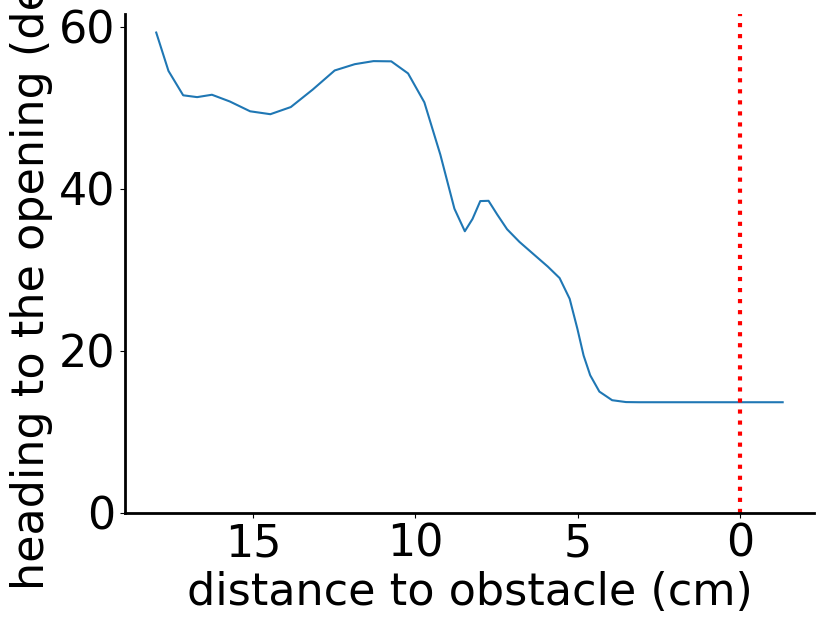

In [8]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
ax.set_xticks([15,10,5,0])
ax.set_yticks([0,20,40,60])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_light.pdf",dpi = 300, transparent=True)

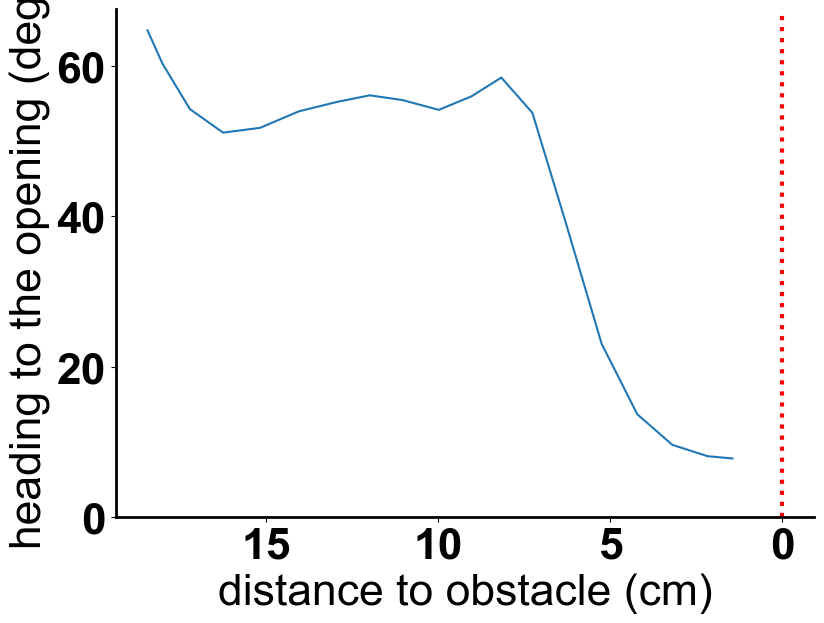

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
ax.set_xticks([15,10,5,0])
ax.set_yticks([0,20,40,60])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)


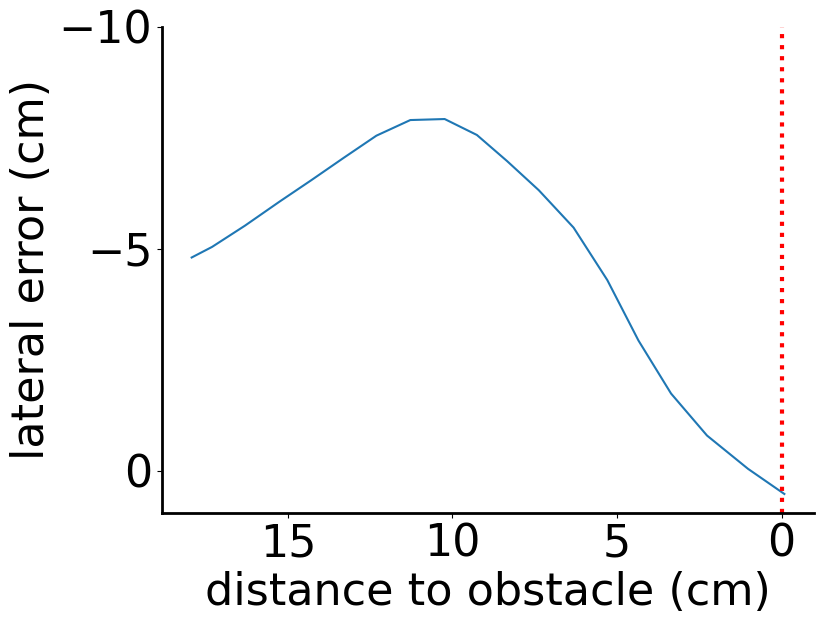

In [9]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
ax.set_yticks([0,-5,-10])
ax.set_xticks([15,10,5,0])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_light.pdf",dpi = 300, transparent=True)

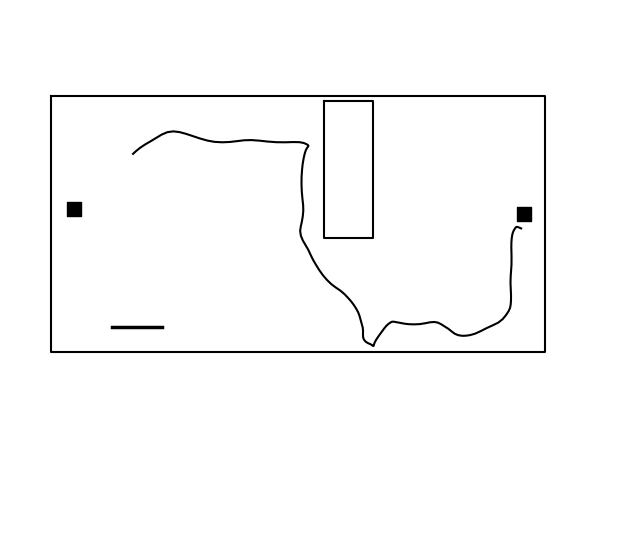

In [61]:
data = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oadark')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')]
data =data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
sample_dark = data.sample(1)
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

for ind,row in sample_dark.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'black')
        
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(30,30),c ='black', linewidth = 2.5)

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\single_trace_dark.pdf",dpi = 300, transparent=True)

In [ ]:
data = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oadark')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')]
data =data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
sample_dark = data.sample(1)
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

for ind,row in sample_dark.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'black')
        
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(30,30),c ='black', linewidth = 2.5)

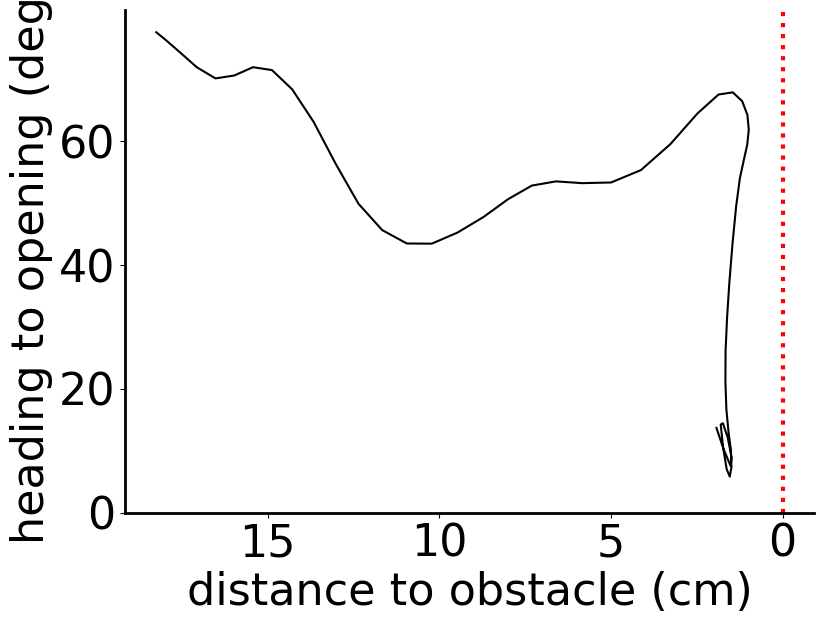

In [62]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to opening (deg)')
ax.plot(smooth(x1),smooth(y1),c ='black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.set_xticks([15,10,5,0])
#ax.set_yticks([0,20,40,60])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.set_xticks([15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_dark.pdf",dpi = 300, transparent=True)

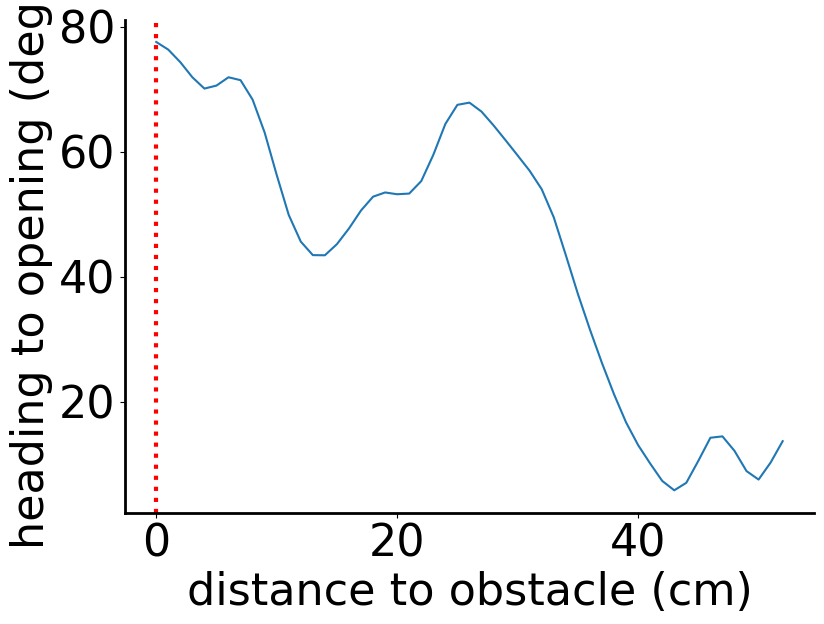

In [63]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to opening (deg)')
ax.plot(smooth(y1))
#ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.set_xticks([15,10,5,0])
#ax.set_yticks([0,20,40,60])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
#ax.set_xticks([15,10,5,0])
#ax.set_yticks([0,20,40,60])
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_dark.pdf",dpi = 300, transparent=True)

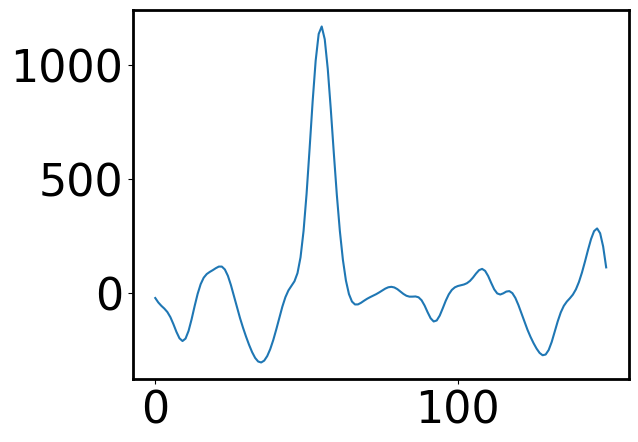

In [70]:
plt.plot(row.head_corner_angle_velocity*60)

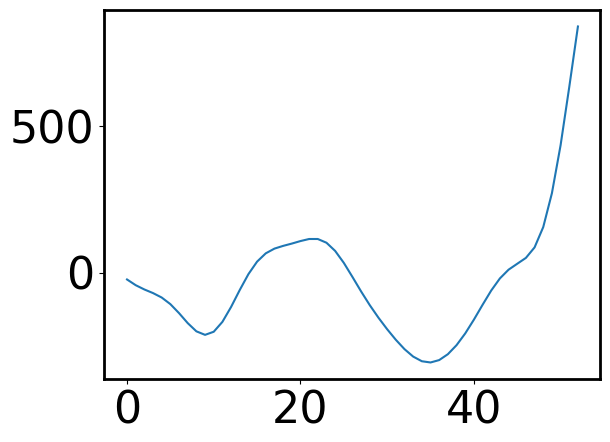

In [69]:
plt.plot(row.head_corner_angle_velocity[:int(row['obstacle_ind'])]*60)

In [71]:
y

array([ -4.05827255,  -4.39907505,  -4.78324526,  -5.07026618,
        -5.39515266,  -5.75440653,  -5.97887038,  -6.25789695,
        -6.57749929,  -7.00884646,  -7.36364843,  -7.70509357,
        -7.89439978,  -8.27522169,  -8.532259  ,  -8.79534458,
        -8.98537063,  -9.2259174 ,  -9.61812056,  -9.89475712,
       -10.04828464, -10.11071001,  -9.99937506,  -9.93323806,
        -9.73451031,  -9.60540522,  -9.51969849,  -9.48389936,
        -9.50101096,  -9.55897989,  -9.45153708,  -9.28064137,
        -9.2478306 ,  -9.31110299,  -9.42969428,  -9.46051014,
        -9.26640346,  -8.91554814,  -8.26821628,  -7.59609867,
        -6.92004576,  -6.11327664,  -5.47036263,  -4.69920529,
        -4.06605571,  -3.50712035,  -3.04969079,  -2.4083493 ,
        -1.79896476,  -1.31287773,  -0.7853827 ,  -0.09731046,
         0.03874894,   0.68126216,   1.1264612 ,   1.47249221,
         2.1245496 ])

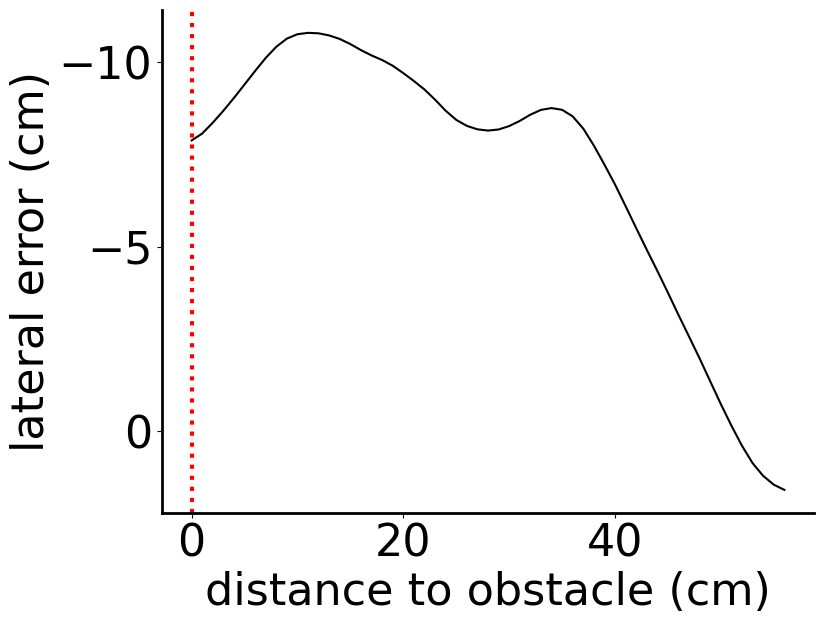

In [54]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(y1),c ='black')
#ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
ax.set_yticks([0,-5,-10])

#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_dark.pdf",dpi = 300, transparent=True)

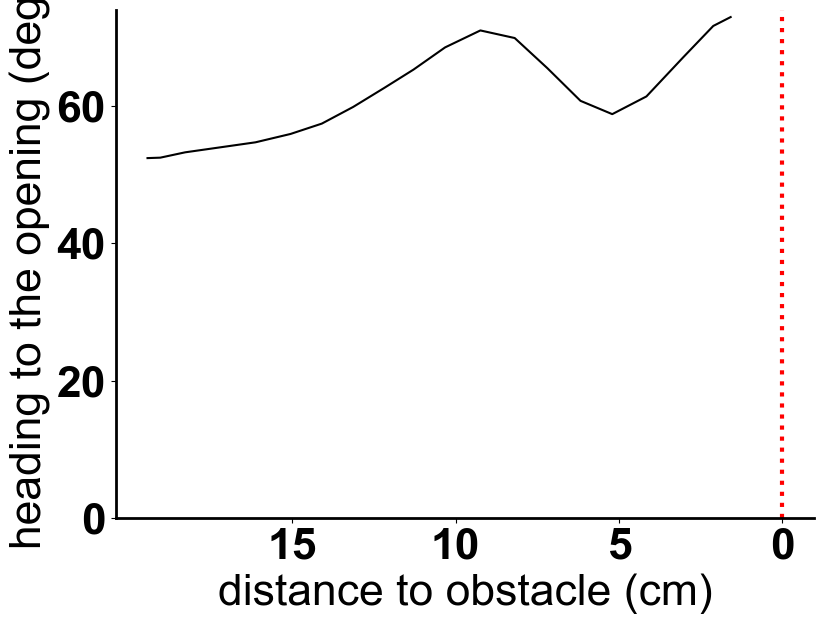

In [69]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c ='black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.set_xticks([15,10,5,0])
#ax.set_yticks([0,20,40,60])
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.set_xticks([15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)


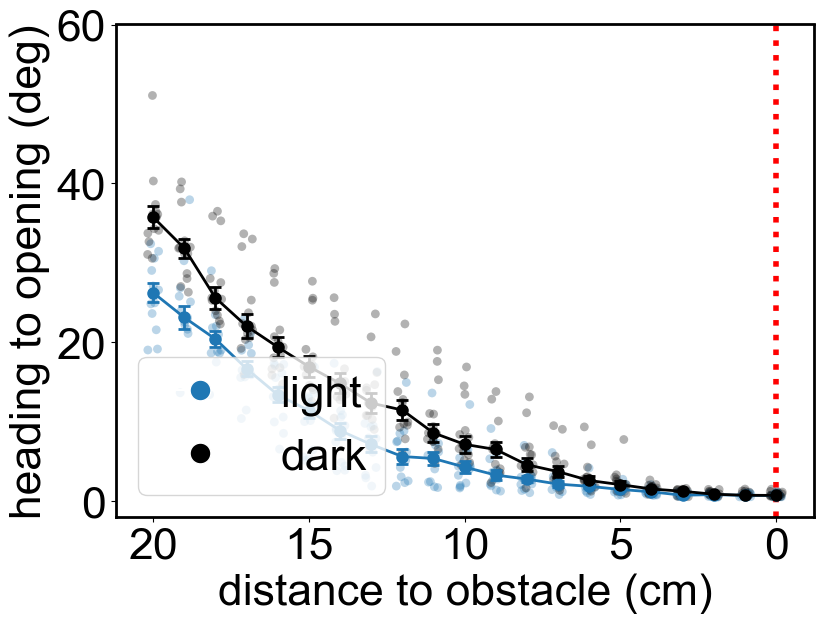

In [5]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[data['obstacle_cluster'].isin([2,3])] 
#data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 


# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_all.pdf",dpi = 300, transparent=True)

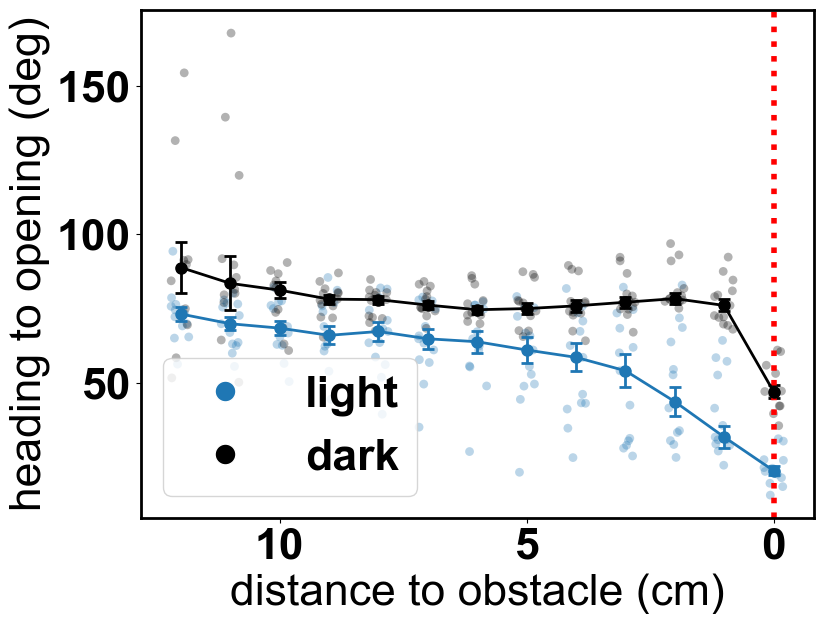

In [7]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 13, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 


# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([10,5,0])
#ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

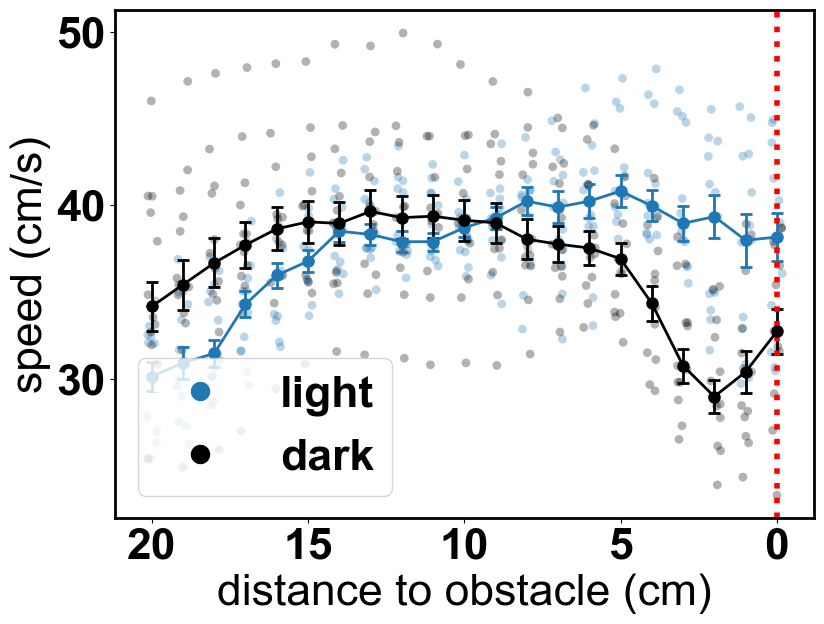

In [8]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = data[~data['obstacle_cluster'].isin([2,3])] 

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[~data.date_index.isin([0])]


# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
#ax.set_yticks([20,40,60])
ax.set_ylabel('speed (cm/s)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"

In [12]:
dark

NameError: name 'dark' is not defined

In [29]:
light_dark[light_dark.task=='oa'].date.unique()

array(['030624', '030724', '030824', '031324', '031224', '031424',
       '031524', '051723', '051823', '051923', '052223', '052323',
       '052523', '052623', '042823', '043023', '050123', '050223',
       '050323', '050423', '050523'], dtype=object)

In [1]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.date_index==2]

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=32)
# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_all.pdf",dpi = 300, transparent=True)

NameError: name 'plt' is not defined

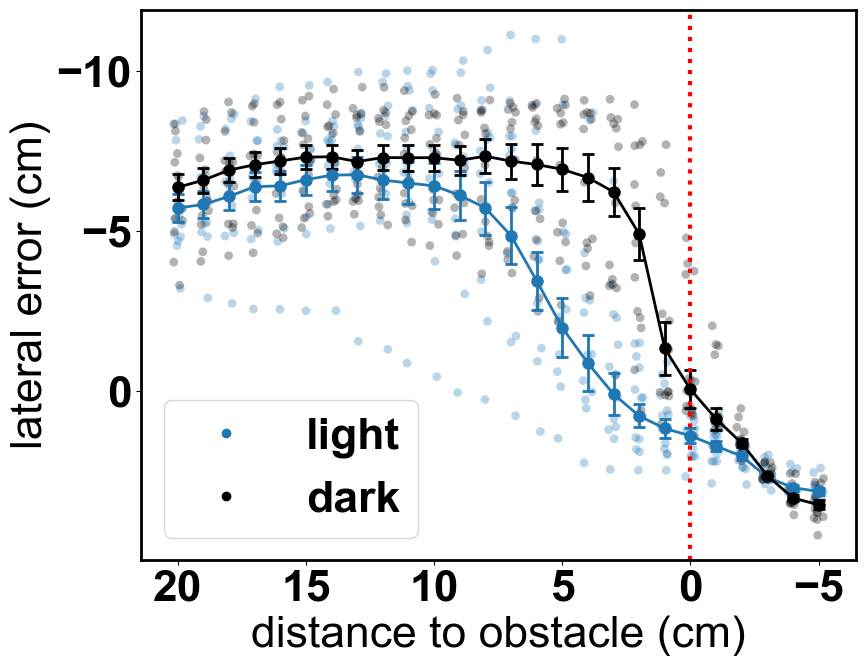

In [31]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(-5, 21, 1)  # Extended from -5 to 20
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.date_index==2]

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        # Extend the data range to include points up to -5 cm past obstacle
        obstacle_idx = int(row[1]['obstacle_ind'])
        # Include some points after the obstacle (extend the window)
        extended_idx = min(obstacle_idx + 10, len(row[1]['ts_distance_from_edge']))  # Add buffer
        
        x = row[1]['ts_distance_from_edge'][:extended_idx].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:extended_idx].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False, fill_value='extrapolate')
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            # Extend the data range to include points up to -5 cm past obstacle
            obstacle_idx = int(row[1]['obstacle_ind'])
            # Include some points after the obstacle (extend the window)
            extended_idx = min(obstacle_idx + 10, len(row[1]['ts_distance_from_edge']))  # Add buffer
            
            x = row[1]['ts_distance_from_edge'][:extended_idx].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:extended_idx].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False, fill_value='extrapolate')
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (updated for extended range)
ax.set_xticks([20,15,10,5,0,-5])  # Added -5 to xticks
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=32)

plt.tight_layout()
plt.show()

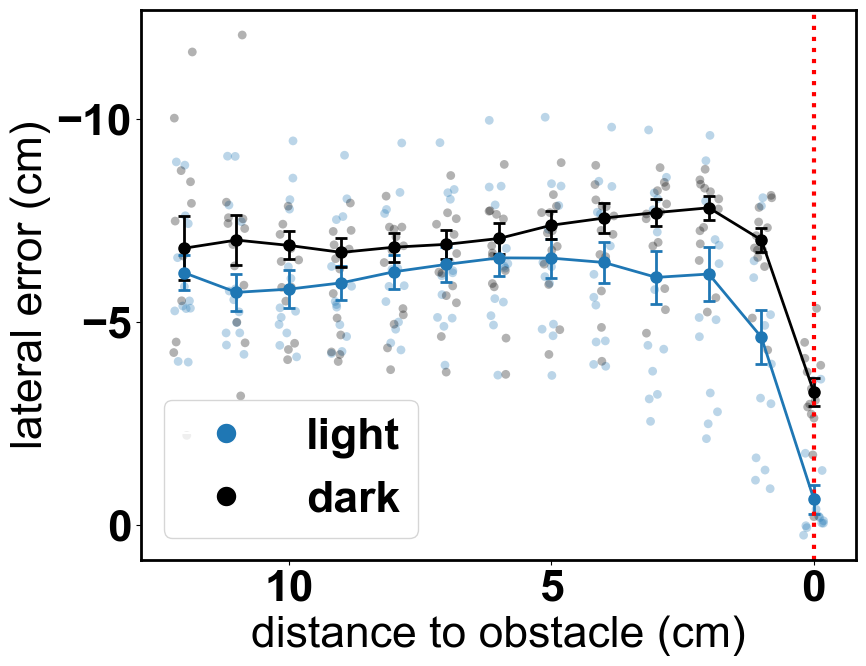

In [222]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 13, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance<=15]  

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
#ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=32)
# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

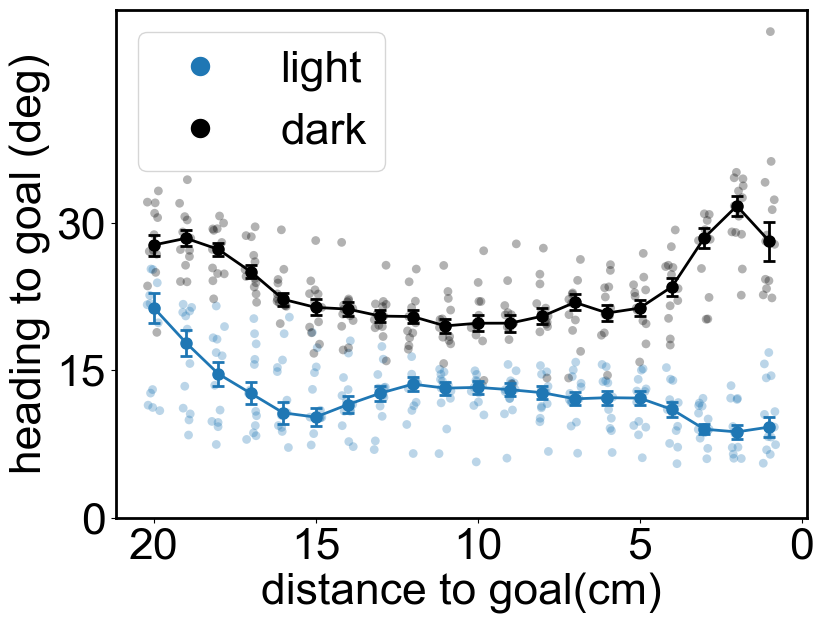

In [6]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_goal.pdf",dpi = 300, transparent=True)

NameError: name 'legend_handles' is not defined

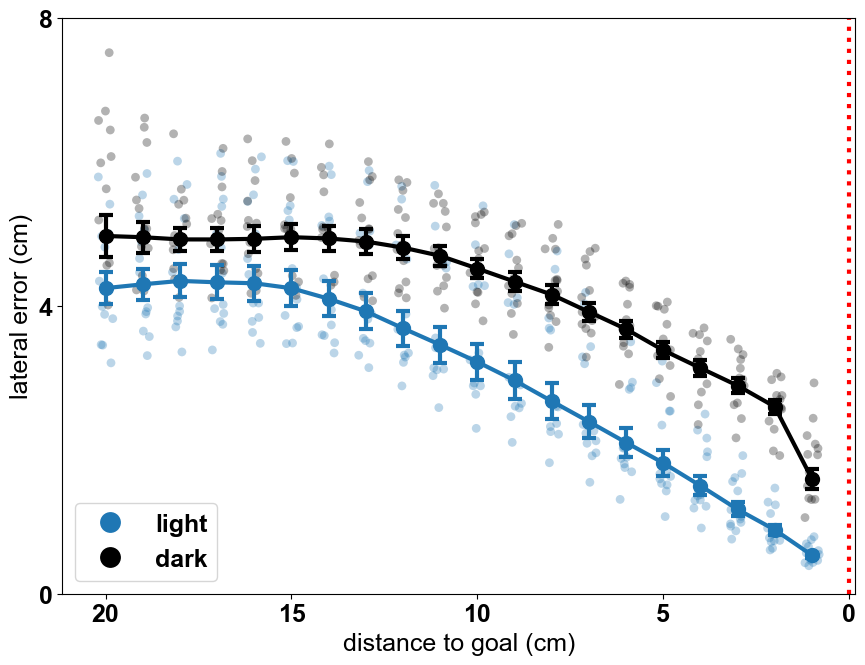

In [4]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\error_goal.pdf",dpi = 300, transparent=True)

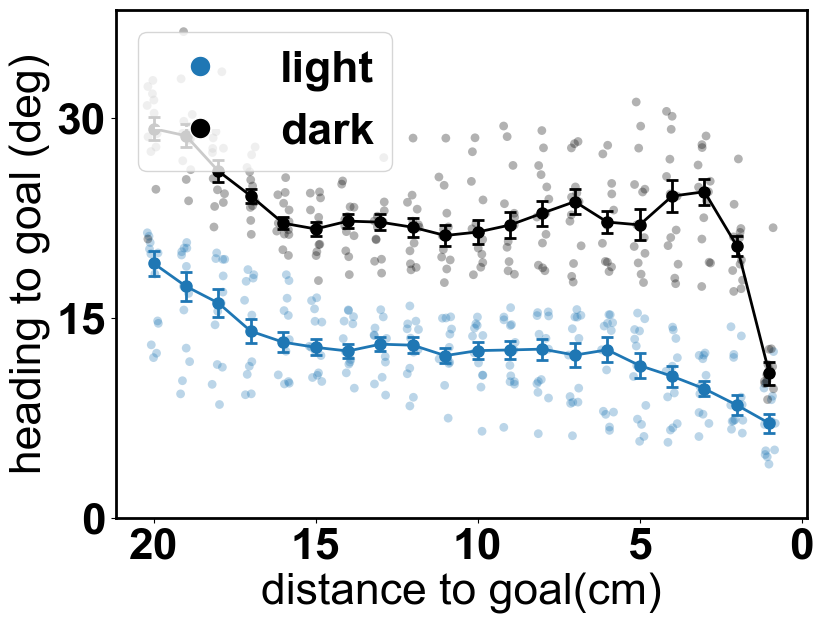

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [134]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_angle_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_goal.pdf",dpi = 300, transparent=True)

In [ ]:
row[1]['goal_distance_from_target_port']

(242,)

In [163]:
row[1]['ts_lateral_error_to_target_port'][:int(row[1]['obstacle_ind'])]

array([8.240804512761255, 8.194898004252742, 8.112185096359102,
       8.007820050966064, 7.898427192439254, 7.797991594543618,
       7.715626422669857, 7.655375045160776, 7.617279422298973,
       7.598824430776803, 7.596287317748024, 7.605976891413993,
       7.6253356516896265, 7.65353627445443, 7.691120520159172,
       7.738647083485887, 7.795034935101446, 7.856564142172493,
       7.917126846603324, 7.969565226867742, 8.00728829084905,
       8.02537948680321, 8.020981502084052, 7.993116851000934,
       7.94234348611891, 7.8704184613127985, 7.779992940990068],
      dtype=object)

In [159]:
row[1]['goal_lateral_error_to_target_port']

array([7.674370311729909, 7.55735145360331, 7.433165971869364,
       7.306357882642029, 7.181485505715369, 7.0627396939755105,
       6.95362548712232, 6.856894201787428, 6.774599935829297,
       6.708018507127113, 6.6572956044624725, 6.620922850361358,
       6.59537321196156, 6.575239640186448, 6.553951536806714,
       6.524916606397136, 6.482640574825666, 6.423337688002391,
       6.344862056448086, 6.246162803417018, 6.126744357521485,
       5.986393848158185, 5.82500161768437, 5.642225236081636,
       5.43705241667282, 5.207769460366837, 4.952691495288548,
       4.671479791152592, 4.366215873097868, 4.041512282171496,
       3.7034464741000974, 3.3579842401447664, 3.009661069044025,
       2.661135236285478, 2.3136225902102403, 1.9678786936213868,
       1.625173519543015, 1.2878388224640887, 0.9591473509844306,
       0.6426586445275255, 0.3413561610213769, 0.057033582112790526,
       0.2097687600310998, 0.45939270722187686, 0.6926111916756668,
       0.9105186020729725, 1

In [153]:
distance_calcs(light_dark)

In [164]:
goal_port(light_dark)

In [157]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)
    

interpolater(xnew)
    

In [181]:
interpolater(xnew)
    

ZeroDivisionError: float division by zero

In [179]:
xnew

array([20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,
        3,  2,  1,  0])

In [188]:
y1.shape

(9,)

In [189]:
x1.shape

(24,)

In [191]:
y

array([8.09073799, 8.09781571, 8.10489343, 8.11197115, 8.11904888,
       8.21501051, 8.00117132, 8.00069027, 6.90602524, 6.79537204,
       7.02701071, 7.07936609, 7.03574523, 7.33070852, 7.38160947,
       7.27296009, 7.23048048, 7.18272327, 7.14246511, 7.07061299,
       6.88642498, 6.97293417, 6.92109766, 6.80048907, 6.35015029,
       5.97619943, 5.60282317, 5.17420524, 4.89369333, 4.7822187 ,
       4.72440922, 4.55621991, 4.36051062, 4.38680575, 4.29738506,
       4.18202487, 4.03216585, 3.83982191, 3.76486321, 3.73011887,
       3.53903428, 3.59207308, 3.62985367, 3.70299036, 3.57175225,
       3.35220947, 2.88360941, 2.85510742, 2.89152515, 2.78397322,
       2.65194287, 2.26009433, 1.9384816 , 1.68624873, 1.45789313,
       1.00401516, 0.78837518, 0.42241438, 0.31527648, 0.52301664,
       0.64895724, 0.80451454, 0.78501248, 0.80435662, 0.70496063,
       0.61960861, 0.56669854, 0.44177842, 0.35478752, 0.24799863,
       0.04114164, 0.13543652, 0.07185244, 0.07185244, 0.07185

In [190]:
x

array([23.53062297, 23.12728048, 22.72501948, 22.32389843, 21.92397991,
       21.44438415, 20.73183826, 20.10381432, 18.86708217, 18.25331635,
       18.14201746, 18.00461479, 17.61434653, 17.46725488, 17.03039698,
       16.68117754, 16.46331407, 16.23390402, 15.70457502, 15.06786896,
       14.77525212, 14.47570339, 14.3042412 , 14.10264369, 13.62042563,
       13.36312075, 13.07339538, 12.8607469 , 12.69368013, 12.51614919,
       12.34494012, 11.97496358, 11.51041442, 11.29541168, 11.03942487,
       10.6349317 , 10.30784465, 10.16136963,  9.66384885,  9.2775109 ,
        8.86466782,  8.55212823,  8.22727807,  7.85223857,  7.54476592,
        7.34189852,  7.03942283,  6.87824508,  6.41137982,  5.9642097 ,
        5.57609456,  4.9515054 ,  4.46099073,  4.07553241,  3.62463261,
        3.06224401,  2.59241907,  2.22110108,  1.95602796,  1.59469475,
        1.48364028,  1.36077075,  1.32339028,  1.28820552,  1.14069574,
        1.06856781,  0.91845521,  0.85789468,  0.8041175 ,  0.71

ValueError: cannot reshape array of size 0 into shape (0,newaxis)

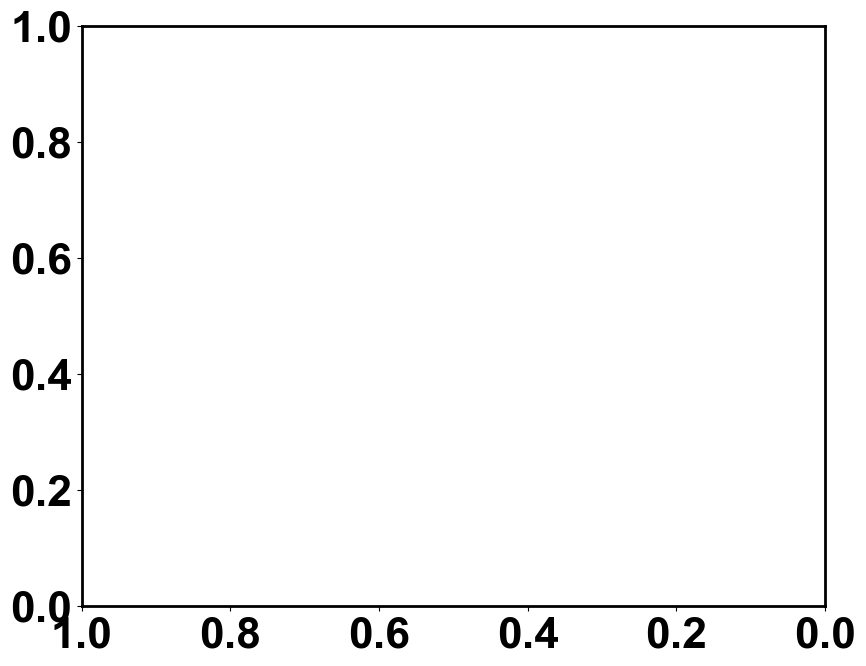

In [7]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['goal_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['goal_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

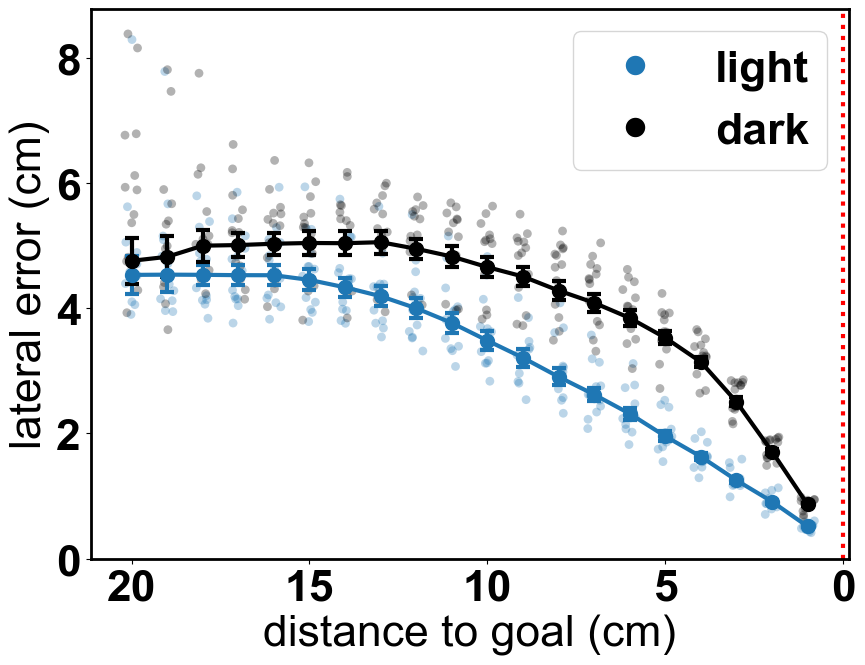

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [207]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['goal_distance_from_target_port'].astype(float)
        x1 = x
        y = row[1]['goal_lateral_error_to_target_port'].astype(float)
        y1 = y
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'].astype(float)
            x1 = x
            y = row[1]['goal_lateral_error_to_target_port'].astype(float)
            y1 = y
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,6,4,2,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_goal.pdf",dpi = 300, transparent=True)

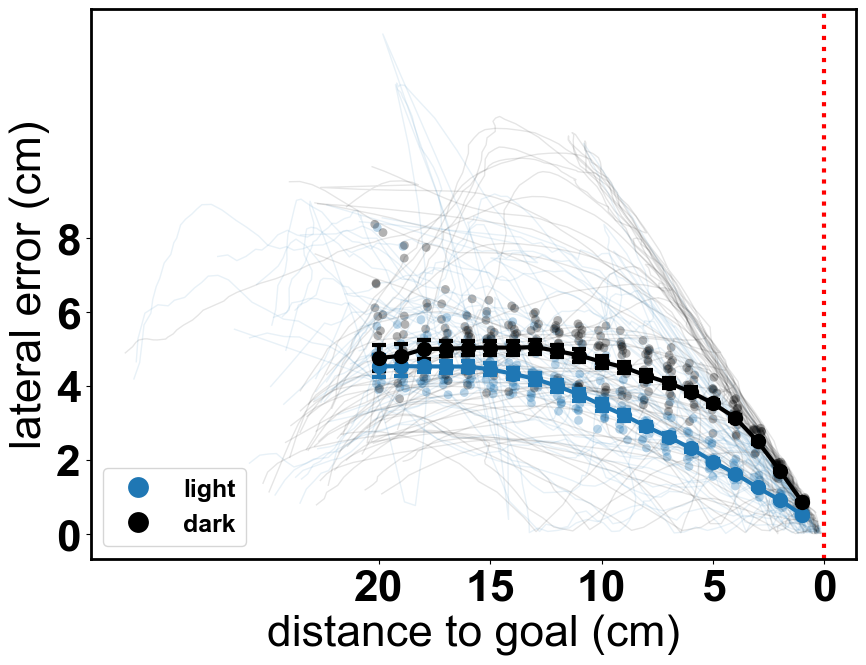

In [263]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points
light_traces = []   # Store individual light traces
dark_traces = []    # Store individual dark traces

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['goal_distance_from_target_port'].astype(float)
        x1 = x
        y = row[1]['goal_lateral_error_to_target_port'].astype(float)
        y1 = y
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
            # Store individual traces
            if task == 'oa' and len(light_traces) < 50:
                light_traces.append((x, y))
            elif task != 'oa' and len(dark_traces) < 50:
                dark_traces.append((x, y))
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'].astype(float)
            x1 = x
            y = row[1]['goal_lateral_error_to_target_port'].astype(float)
            y1 = y
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual traces first (so they're behind)
for x, y in light_traces:
    ax.plot(x, y, color='tab:blue', alpha=0.1, linewidth=1)
for x, y in dark_traces:
    ax.plot(x, y, color='black', alpha=0.1, linewidth=1)

# Plot individual points next
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,6,4,2,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)

# Legend with larger markers
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [218]:
np.std(row.ts_speed)

8.749014423561858

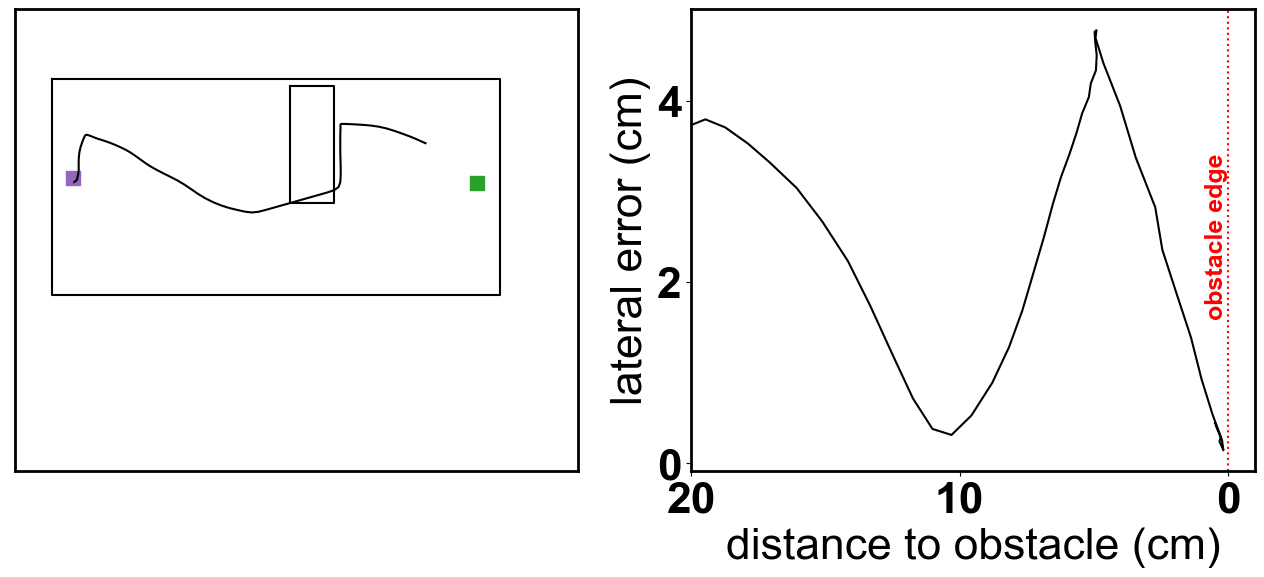

In [270]:
data = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.task == 'oadark')&(light_dark.head_corner_angle_velocity_at_head_turn <= -5)]
sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots(1,2,figsize=(16,6))
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('lateral error (cm)')
    ax[1].set_xlabel('distance to obstacle')
   
    plot_arena(sample,ax[0])
    plot_orginal_obstacle(sample,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        ax[1].set_xlabel('distance to obstacle (cm)')
        ob_ind = int(row.obstacle_ind)
  
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'black')
        ax[1].plot(row.goal_distance_from_target_port,smooth(row.goal_lateral_error_to_target_port),color = 'black')
        ax[1].axvline(0, color='r', ls=':')
        ax[1].text(0, ax[1].get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90)

In [203]:
np.nanmean([np.nanmean(row[1]['rightportB_y_cm']),row[1]['rightportT_y_cm']])

23.173472784150963

In [202]:
np.nanmean([np.nanmean(row[1]['leftportB_y_cm']),row[1]['leftportT_y_cm']])

21.67247094157453

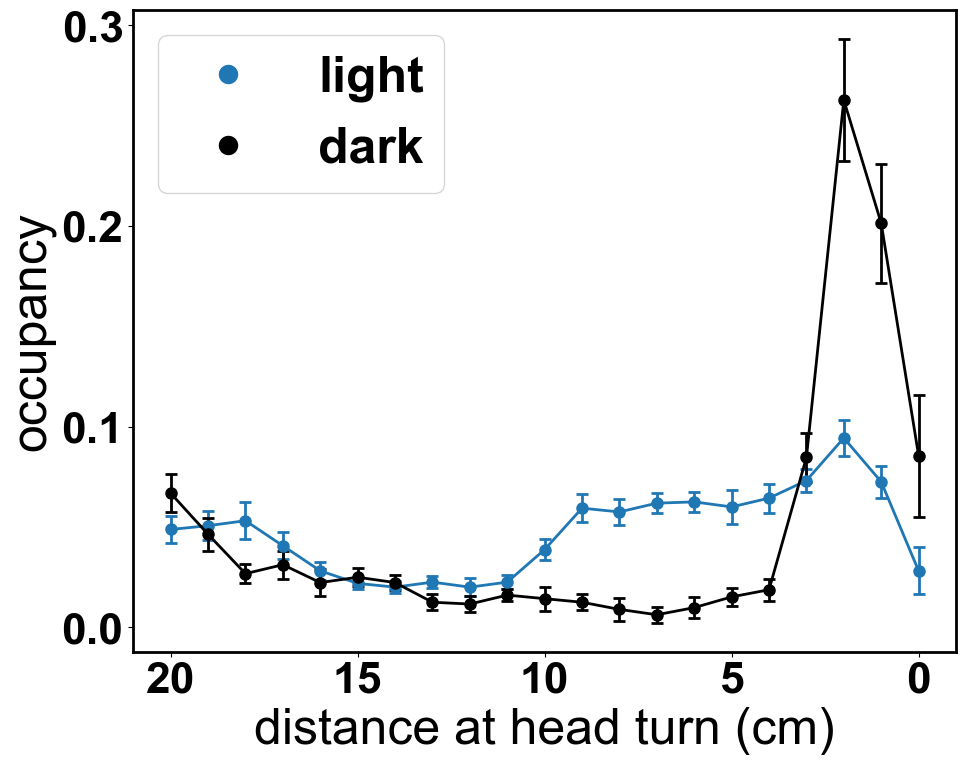

In [223]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(0, 21, 1)
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.avg_lateral_error<0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
#for x_jittered, y in light_scatter:
#    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
#for x_jittered, y in dark_scatter:
#    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_xticks([20,15, 10, 5, 0])
ax.set_yticks([0,.1,.2,.3])

ax.set_ylabel('occupancy', fontsize=36)  # lowercase
ax.set_xlabel('distance at head turn (cm)', fontsize=36)  # lowercase
ax.invert_xaxis()
#ax.set_xlim(15,-.3)

# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=36, framealpha=0.8)

plt.tight_layout()
plt.show()


(array([3.45000e+02, 1.09500e+03, 1.96760e+04, 5.51010e+04, 5.06540e+04,
        1.15705e+05, 8.55980e+04, 3.29260e+04, 1.42000e+03, 1.60000e+01]),
 array([-23.31720477, -19.15847672, -14.99974868, -10.84102063,
         -6.68229258,  -2.52356453,   1.63516351,   5.79389156,
          9.95261961,  14.11134766,  18.2700757 ]),
 <BarContainer object of 10 artists>)

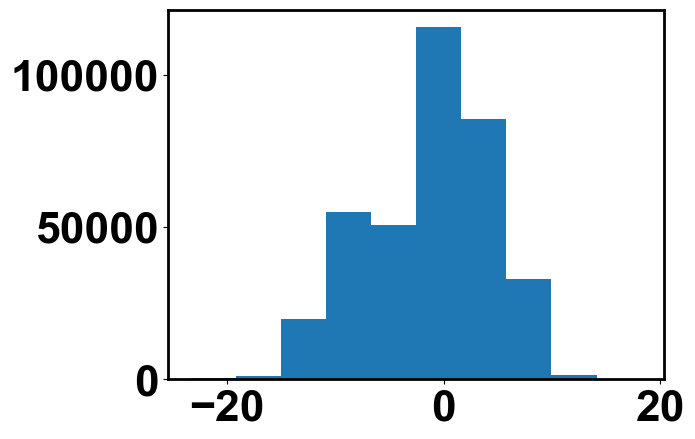

In [227]:
plt.hist(flatten_list_of_arrays(light.lateral_error.to_list()))

(array([2.28827089e-04, 7.26277281e-04, 1.30504400e-02, 3.65466707e-02,
        3.35971227e-02, 7.67432994e-02, 5.67743221e-02, 2.18387267e-02,
        9.41839031e-04, 1.06122708e-05]),
 array([-23.31720477, -19.15847672, -14.99974868, -10.84102063,
         -6.68229258,  -2.52356453,   1.63516351,   5.79389156,
          9.95261961,  14.11134766,  18.2700757 ]),
 <BarContainer object of 10 artists>)

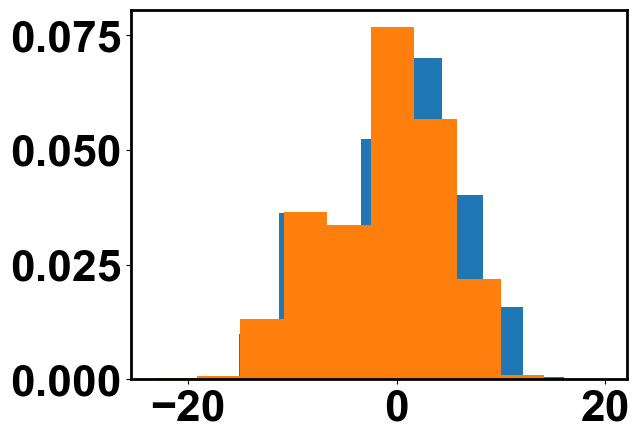

In [230]:
plt.hist(flatten_list_of_arrays(dark.lateral_error.to_list()),density =True)
plt.hist(flatten_list_of_arrays(light.lateral_error.to_list()),density =True)

In [231]:
ROW

NameError: name 'ROW' is not defined

In [241]:
np.where((0>=row[1].ts_distance_from_edge)& (row[1].ts_distance_from_edge>=-5))

(array([62, 63, 64, 65, 66, 67, 68, 69, 70], dtype=int64),)

In [243]:
row[1].lateral_error[np.where((0>=row[1].ts_distance_from_edge)& (row[1].ts_distance_from_edge>=-5))]

array([0.685918852186088, 1.0244188500409983, 1.3348671245985706,
       1.6190083404829672, 1.8776899784317926, 2.1114306684442425,
       2.3210103801686017, 2.507760489953572, 2.673489584894295],
      dtype=object)

In [246]:
row

level_0                                                                             98
first_poke                                                                48966.936755
second_poke                                                               48973.421184
trial_timestamps                     [48966.9488, 48966.965478, 48966.982169, 48966...
trial_vidframes                      [55425, 55426, 55427, 55428, 55429, 55430, 554...
                                                           ...                        
turn_direction_left_right                                                        right
intial_distance                                                                   21.0
goal_distance_from_target_port       [22.529986906267396, 22.17968336735737, 21.829...
goal_angle_to_target_port            [1.3314485772161861, 1.7714984719028593, 2.195...
goal_lateral_error_to_target_port    [8.646406753675207, 8.583746929418034, 8.52108...
Name: 98, Length: 286, dtype: object

1.5122694471676112


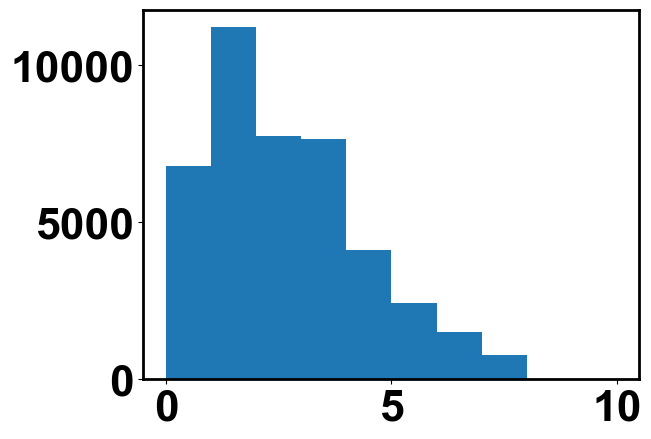

In [260]:
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
light = data[data.task=='oa']
lateral_error_next_obstacle = []
for ind,row in light.iterrows():
    lateral_error = row.lateral_error[np.where((2>=row.ts_distance_from_edge)& (row.ts_distance_from_edge>=-8))]
    lateral_error_next_obstacle.append(lateral_error)
lateral_error_next_obstacle = flatten_list_of_arrays(lateral_error_next_obstacle)
plt.hist(lateral_error_next_obstacle,range = (0,10))
print(np.nanmedian(lateral_error_next_obstacle))


1.0792412786799943


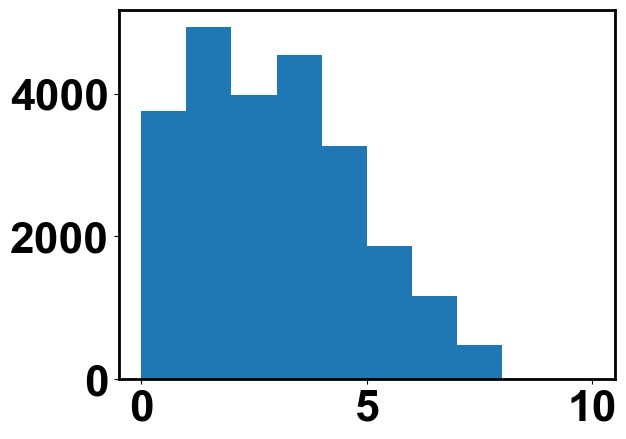

In [261]:
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
light = data[data.task=='oadark']
lateral_error_next_obstacle = []
for ind,row in light.iterrows():
    lateral_error = row.lateral_error[np.where((2>=row.ts_distance_from_edge)& (row.ts_distance_from_edge>=-8))]
    lateral_error_next_obstacle.append(lateral_error)
lateral_error_next_obstacle = flatten_list_of_arrays(lateral_error_next_obstacle)
plt.hist(lateral_error_next_obstacle,range = (0,10))
print(np.nanmedian(lateral_error_next_obstacle))

In [9]:
data.time

423      3.400000
425      3.616667
428      4.250000
433      3.266667
434      5.233333
           ...   
14521    3.500000
14523    2.650000
14526    2.616667
14531    2.916667
14539    2.350000
Name: time, Length: 2888, dtype: float64

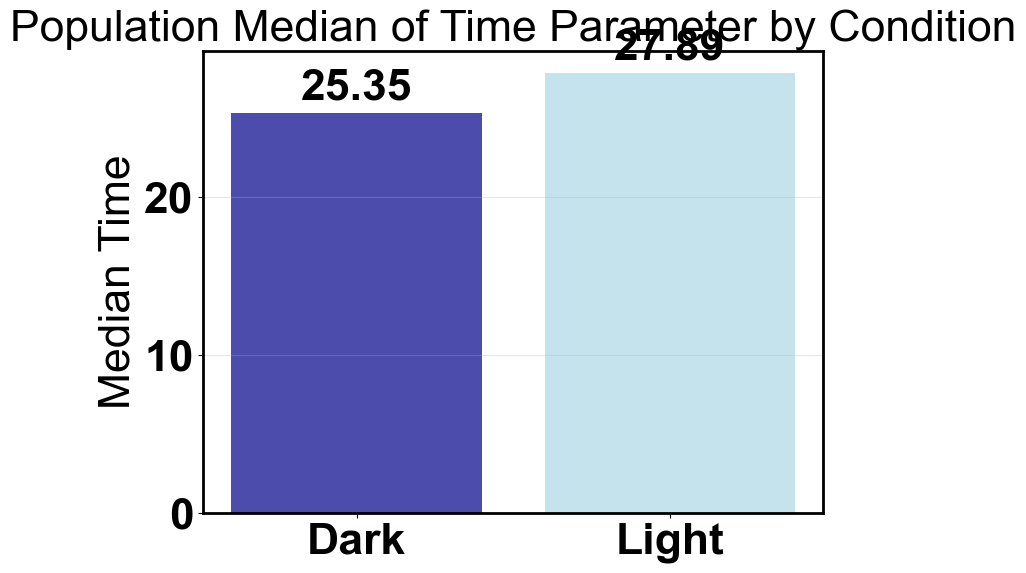

In [11]:
data = pd.concat([light_dark])
dark = data[data.task=='oadark']
light = data[data.task=='oa']

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate medians for each condition
dark_median = dark['avg_speed'].median()
light_median = light['avg_speed'].median()

# Create a bar plot
plt.figure(figsize=(8, 6))
conditions = ['Dark', 'Light']
medians = [dark_median, light_median]

plt.bar(conditions, medians, color=['darkblue', 'lightblue'], alpha=0.7)
plt.ylabel('Median Time')
plt.title('Population Median of Time Parameter by Condition')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(medians):
    plt.text(i, v + max(medians)*0.01, f'{v:.2f}', ha='center', va='bottom')

plt.show()

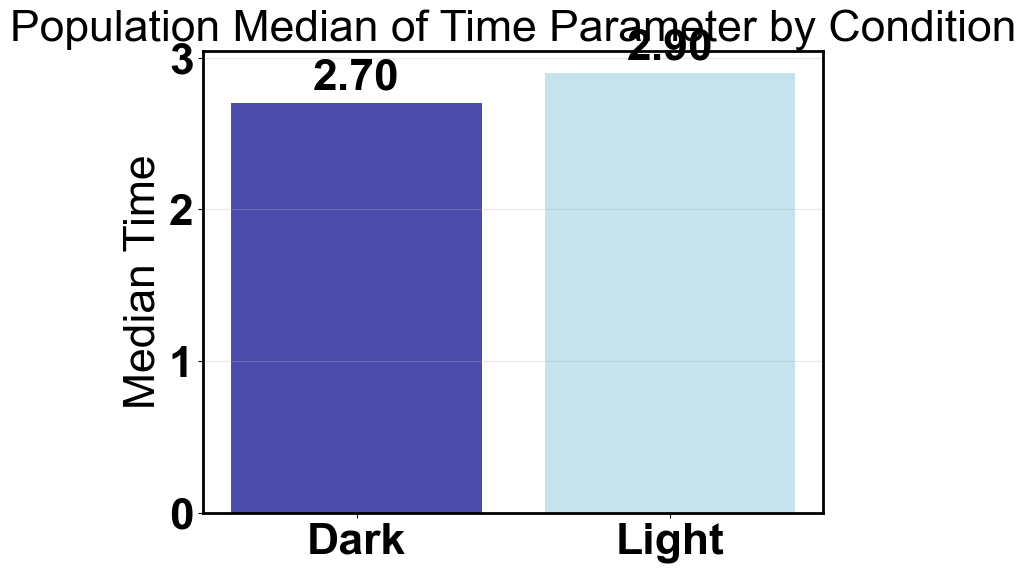

In [10]:
data = pd.concat([light_dark])
dark = data[data.task=='oadark']
light = data[data.task=='oa']

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate medians for each condition
dark_median = dark['time'].median()
light_median = light['time'].median()

# Create a bar plot
plt.figure(figsize=(8, 6))
conditions = ['Dark', 'Light']
medians = [dark_median, light_median]

plt.bar(conditions, medians, color=['darkblue', 'lightblue'], alpha=0.7)
plt.ylabel('Median Time')
plt.title('Population Median of Time Parameter by Condition')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(medians):
    plt.text(i, v + max(medians)*0.01, f'{v:.2f}', ha='center', va='bottom')

plt.show()